# EEG Eye-State · Causal Random Forest — Predict T+1 from Window T

Given **T consecutive EEG samples** across all channels, predict whether  
the eyes will be **open or closed at the very next sample** (T+1).

```
t-T+1   t-T+2  ...   t          t+1
  |       |     ...   |            |
 [————————— input window ————————] → predict label here
   (C channels × T timesteps → flattened → C×T features)
```

### Differences from the Conv1D version

| | Causal Conv1D | This notebook |
|---|---|---|
| Model | Conv1D (learns temporal filters) | **Random Forest** (ensemble of decision trees) |
| Input format | `(batch, C, T)` 3-D tensor | `(n_samples, C×T)` **flattened** 2-D array |
| GPU | MPS / CUDA | **CPU only** (sklearn) — but RF parallelises via `n_jobs=-1` |
| Optuna params | arch + T + optimiser | **T + RF hyperparams** |
| Interpretability | filter visualisation | **feature importance** per (channel, lag) pair |

> The flattened feature vector preserves all temporal information:  
> feature `i*T + j` = channel `i` at lag `j` steps before the target.


## 1 · Imports & Setup

In [32]:
import sys

sys.path.insert(0, "..")
from src.preprocessing import build_windows, load_trial, make_horizon_labels

In [33]:
import warnings

warnings.filterwarnings("ignore")
import logging
import os

import numpy as np
import optuna
import pandas as pd
import scipy
from mne.filter import filter_data
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler
from scipy.io import arff
from scipy.signal import welch
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler

optuna.logging.set_verbosity(optuna.logging.WARNING)

import matplotlib
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt

from src.preprocessing import build_windows

# colour palette
DARK = "#0a0e17"
CARD = "#111827"
EDGE = "#1f2937"
TEAL = "#00e5cc"
CORAL = "#ff4f5e"
GOLD = "#ffc947"
LIME = "#a8ff3e"
WHITE = "#f0f4ff"
GRAY = "#6b7280"

print("All imports OK.")

All imports OK.


## 2 · Load Dataset

In [ ]:
print("Loading dataset …")
FS = 250
DECIMATE = 4   # downsampling factor after filtering (1 = off, 2 → 125 Hz, 4 → 62.5 Hz)
STRIDE   = 8   # window stride in samples (1 = dense, 4 = one window per ~16 ms)

subject = 9
tache = "spt"
trial = 0
data_path = f"../data/subject{subject}/"

df, EEG_COLS = load_trial(subject, tache, trial, data_path, apply_filter=False, decimate=DECIMATE)
TARGET = "button"
N_CHANNELS = len(EEG_COLS)
FS_EFF = FS // DECIMATE   # effective fs after decimation
HORIZON = int(1.0 * FS_EFF)  # anticipatory label lookahead: 1000 ms (full Bereitschaftspotential)

print(f"  Shape    : {df.shape}")
print(f"  Channels ({len(EEG_COLS)}): {EEG_COLS}")
print(f"  Class balance:\n{df[TARGET].value_counts()}\n")
print(f"  Effective FS : {FS_EFF} Hz  (DECIMATE={DECIMATE}, STRIDE={STRIDE})")
print(f"  HORIZON      : {HORIZON} samples  ({HORIZON/FS_EFF*1000:.0f} ms lookahead)")
print(f"  Note: T in Optuna/build_windows is in samples at FS_EFF={FS_EFF} Hz")

## 3 · Artifact Removal

Interpolate samples outside the `[q_lower, q_upper]` quantile range per channel.  
Toggle `APPLY_CLEANING = False` to skip.


APPLY_CLEANING = True
Q_UPPER, Q_LOWER, MARGIN = 0.999, 0.001, 5


def remove_artifacts_interpolate(df, eeg_cols, q_upper=0.999, q_lower=0.001, margin=5):
    df_c = df.copy()
    total = 0
    for ch in eeg_cols:
        col = df_c[ch].copy().astype(float)
        bad = (col > col.quantile(q_upper)) | (col < col.quantile(q_lower))
        bad_exp = bad.copy()
        for s in range(1, margin + 1):
            bad_exp |= bad.shift(s, fill_value=False)
            bad_exp |= bad.shift(-s, fill_value=False)
        col[bad_exp] = np.nan
        df_c[ch] = col.interpolate(method="linear", limit_direction="both")
        total += bad_exp.sum()
    print(f"Replaced {total} sample-channel values.")
    return df_c


if APPLY_CLEANING:
    df = remove_artifacts_interpolate(df, EEG_COLS, Q_UPPER, Q_LOWER, MARGIN)
else:
    print("Artifact removal skipped.")

df.iloc[:, 1:-1] = filter_data(df.iloc[:, 1:-1].values.T, FS, 0.1, 60).T

## 3.5 · ICA Artifact Rejection

Independent Component Analysis (ICA) decomposes the filtered EEG into statistically
independent source signals. Artifacts (eye blinks, muscle activity, electrode drift)
tend to segregate into a small number of components that can be removed without
distorting the brain signal.

**Workflow:**
1. Run the cell below — it fits FastICA and shows 3 diagnostic plots
2. Decide which components to exclude based on the plots
3. Edit `EXCLUDE_COMPONENTS = [...]` in the next cell and run it
4. Run the apply cell — it reconstructs `df[EEG_COLS]` with those components zeroed out

| Plot | What to look for |
|---|---|
| Mixing matrix | Columns with one dominant channel → likely electrode artifact |
| Time series | Low-freq bursty waveform → eye blink; high-freq chaotic → muscle |
| PSD | Flat spectrum above 20 Hz → muscle; sharp 50/60 Hz line → powerline |

ICA fitted in 2000 iterations | sources: (5085, 16)


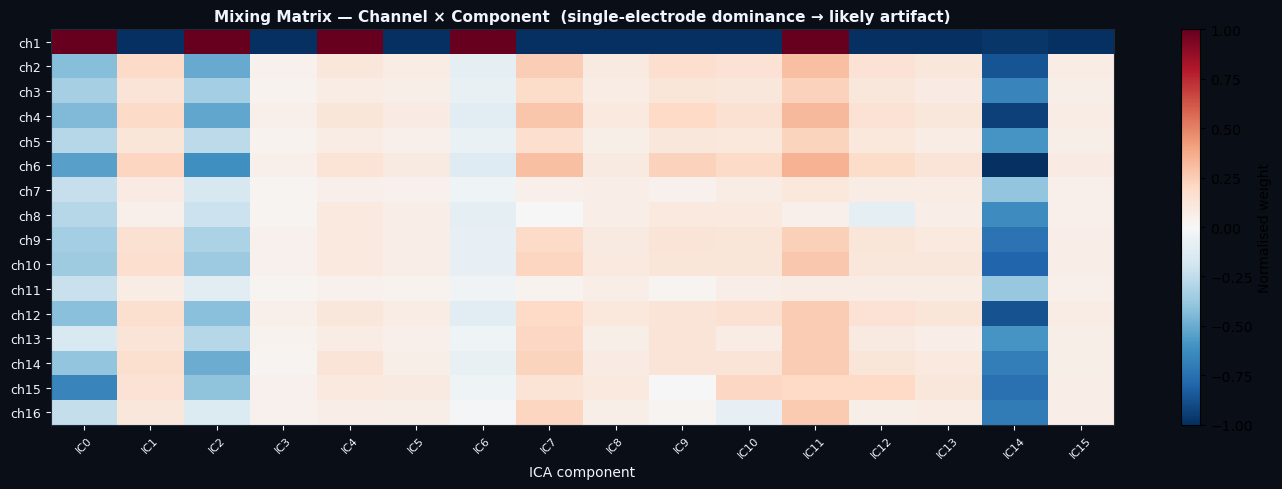

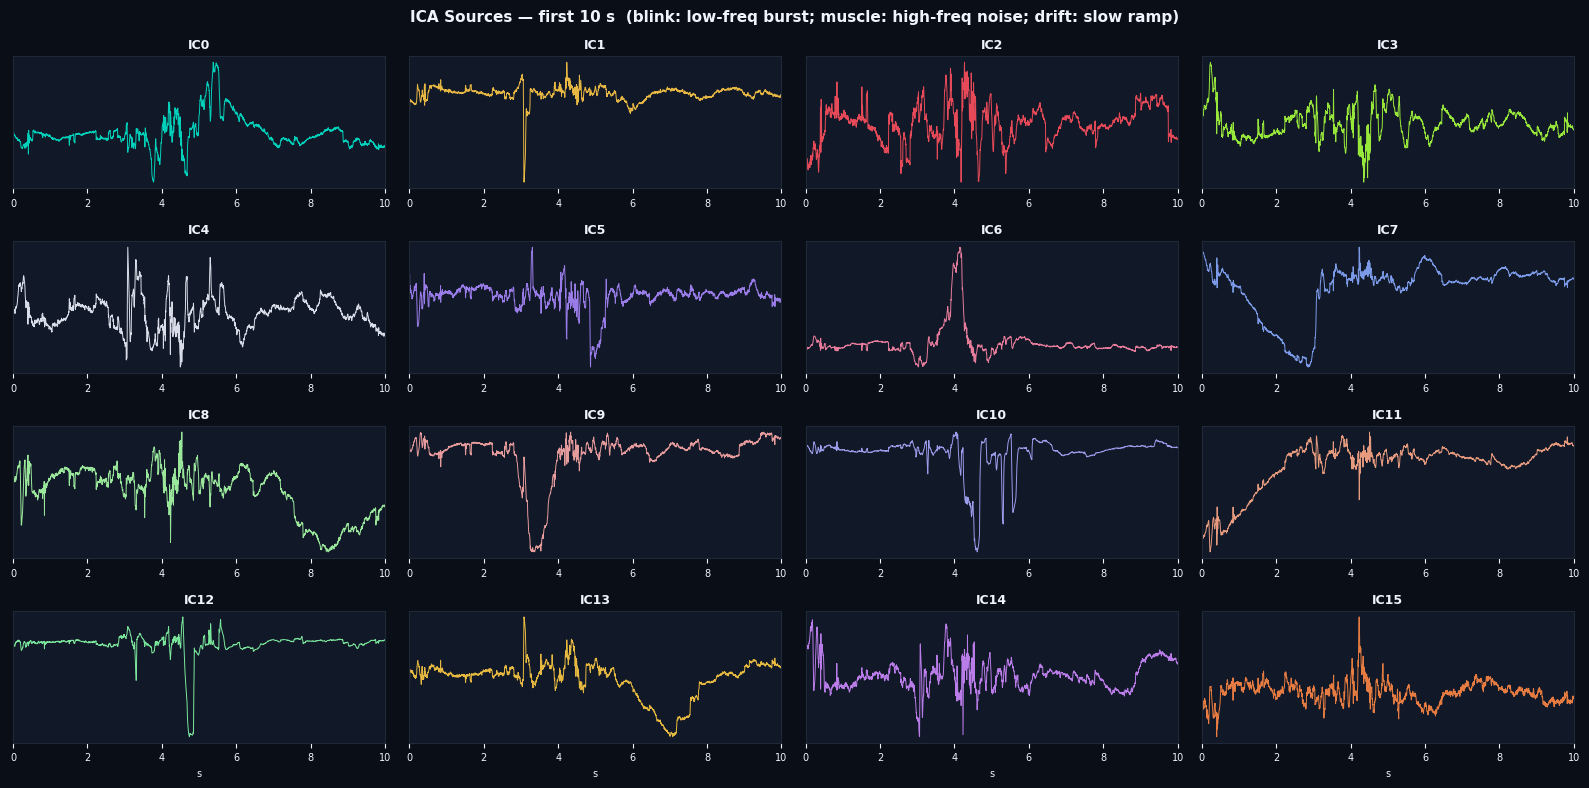

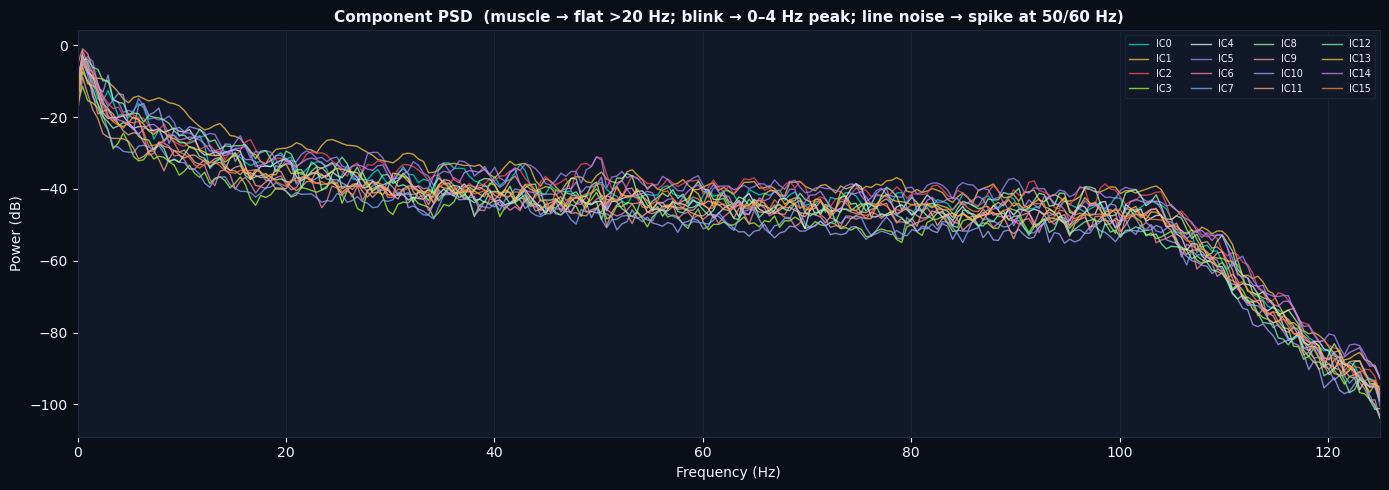


→ Inspect the 3 plots above.
→ Edit EXCLUDE_COMPONENTS in the next cell, then run the apply cell.


In [4]:
%matplotlib inline
from sklearn.decomposition import FastICA

N_ICA_COMPONENTS = N_CHANNELS
ICA_MAX_ITER = 2000

# ── Fit ICA on filtered data ───────────────────────────────────────────────
X_filt = df[EEG_COLS].values.astype(np.float32)
ica = FastICA(
    n_components=N_ICA_COMPONENTS,
    max_iter=ICA_MAX_ITER,
    random_state=42,
    whiten="unit-variance",
)
S = ica.fit_transform(X_filt)  # (N, n_components) — independent source signals
print(f"ICA fitted in {ica.n_iter_} iterations | sources: {S.shape}")

# Mixing matrix A: X ≈ S @ A.T + mean_  (columns = channel topographies)
A = ica.mixing_  # (C, n_components)
A_norm = A / (np.abs(A).max(axis=0, keepdims=True) + 1e-8)

_pal = [
    TEAL,
    GOLD,
    CORAL,
    LIME,
    WHITE,
    "#aa88ff",
    "#ff88aa",
    "#88aaff",
    "#aaffaa",
    "#ffaaaa",
    "#aaaaff",
    "#ffaa88",
    "#88ffaa",
    "#ffcc44",
    "#cc88ff",
    "#ff8844",
]

# ── Plot A: mixing-matrix heatmap (channel × component) ───────────────────
fig, ax = plt.subplots(figsize=(14, 5), facecolor=DARK)
ax.set_facecolor(CARD)
for sp in ax.spines.values():
    sp.set_color(EDGE)
im = ax.imshow(
    A_norm, aspect="auto", cmap="RdBu_r", vmin=-1, vmax=1, interpolation="nearest"
)
plt.colorbar(im, ax=ax, label="Normalised weight")
ax.set_xticks(range(N_ICA_COMPONENTS))
ax.set_xticklabels(
    [f"IC{i}" for i in range(N_ICA_COMPONENTS)], color=WHITE, fontsize=8, rotation=45
)
ax.set_yticks(range(N_CHANNELS))
ax.set_yticklabels(EEG_COLS, color=WHITE, fontsize=9)
ax.set_xlabel("ICA component", color=WHITE)
ax.set_title(
    "Mixing Matrix — Channel × Component  "
    "(single-electrode dominance → likely artifact)",
    color=WHITE,
    fontsize=11,
    fontweight="bold",
)
ax.tick_params(colors=WHITE)
plt.tight_layout()
plt.show()

# ── Plot B: component time-series (first 10 s) ────────────────────────────
T_DISP = 10
n_disp = min(int(T_DISP * FS), len(S))
t_ax = np.arange(n_disp) / FS

NCOLS = 4
NROWS = int(np.ceil(N_ICA_COMPONENTS / NCOLS))
fig, axes = plt.subplots(
    NROWS, NCOLS, figsize=(16, NROWS * 2.0), facecolor=DARK, squeeze=False
)
axes_flat = axes.flatten()

for ic in range(N_ICA_COMPONENTS):
    ax = axes_flat[ic]
    ax.set_facecolor(CARD)
    for sp in ax.spines.values():
        sp.set_color(EDGE)
    ax.plot(t_ax, S[:n_disp, ic], color=_pal[ic % len(_pal)], lw=0.7, alpha=0.9)
    ax.set_xlim(0, T_DISP)
    ax.set_yticks([])
    ax.set_title(f"IC{ic}", color=WHITE, fontsize=9, fontweight="bold")
    ax.tick_params(colors=WHITE, labelsize=7)
    if ic >= (NROWS - 1) * NCOLS:
        ax.set_xlabel("s", color=WHITE, fontsize=7)

for ax in axes_flat[N_ICA_COMPONENTS:]:
    ax.set_visible(False)

fig.suptitle(
    f"ICA Sources — first {T_DISP} s  "
    "(blink: low-freq burst; muscle: high-freq noise; drift: slow ramp)",
    color=WHITE,
    fontsize=11,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

# ── Plot C: component PSD ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5), facecolor=DARK)
ax.set_facecolor(CARD)
for sp in ax.spines.values():
    sp.set_color(EDGE)

for ic in range(N_ICA_COMPONENTS):
    freqs, psd = welch(S[:, ic], fs=FS, nperseg=512)
    psd_db = 10 * np.log10(psd + 1e-12)
    ax.plot(
        freqs, psd_db, color=_pal[ic % len(_pal)], lw=1.0, alpha=0.75, label=f"IC{ic}"
    )

ax.set_xlim(0, FS // 2)
ax.set_xlabel("Frequency (Hz)", color=WHITE, fontsize=10)
ax.set_ylabel("Power (dB)", color=WHITE, fontsize=10)
ax.set_title(
    "Component PSD  "
    "(muscle → flat >20 Hz; blink → 0–4 Hz peak; line noise → spike at 50/60 Hz)",
    color=WHITE,
    fontsize=11,
    fontweight="bold",
)
ax.tick_params(colors=WHITE)
ax.xaxis.grid(True, color=EDGE, lw=0.5)
ax.legend(
    facecolor=CARD,
    labelcolor=WHITE,
    edgecolor=EDGE,
    fontsize=7,
    ncol=4,
    loc="upper right",
)
plt.tight_layout()
plt.show()

print("\n→ Inspect the 3 plots above.")
print("→ Edit EXCLUDE_COMPONENTS in the next cell, then run the apply cell.")

In [4]:
# ── Choose which ICA components to remove ─────────────────────────────────
# Inspect the mixing matrix, time series, and PSD plots above.
# Typical artifact signatures:
#   - Eye blinks    : strong weight on Fp1/Fp2 (frontal); low-freq burst in time series
#   - Muscle noise  : strong weight on temporal channels; flat PSD above 20 Hz
#   - Electrode pop : single channel dominates the column; impulse in time series
#   - Line noise    : sharp peak at 50 or 60 Hz in PSD
#
# Example: EXCLUDE_COMPONENTS = [0, 3]

EXCLUDE_COMPONENTS = []  # ← fill in and re-run this cell + the next
print(f"Components to exclude: {EXCLUDE_COMPONENTS}")

Components to exclude: []


In [5]:
if EXCLUDE_COMPONENTS:
    S_clean = S.copy()
    S_clean[:, EXCLUDE_COMPONENTS] = 0.0
    X_clean = ica.inverse_transform(S_clean).astype(np.float32)
    df[EEG_COLS] = X_clean
    print(f"ICA rejection applied — removed IC(s): {EXCLUDE_COMPONENTS}")
    print(f"  Signal shape unchanged : {X_clean.shape}")
else:
    print("No components excluded — df[EEG_COLS] unchanged.")
    print("(To apply: set EXCLUDE_COMPONENTS above and re-run both cells.)")

No components excluded — df[EEG_COLS] unchanged.
(To apply: set EXCLUDE_COMPONENTS above and re-run both cells.)


# ── Decimate to FS_EFF (applied after artifact removal + filter + ICA) ────
if DECIMATE > 1:
    from scipy.signal import decimate as sp_decimate
    eeg_decimated = sp_decimate(df[EEG_COLS].values, DECIMATE, axis=0, zero_phase=True)
    n_out = eeg_decimated.shape[0]
    df = df.iloc[::DECIMATE].iloc[:n_out].reset_index(drop=True)
    df[EEG_COLS] = eeg_decimated
    print(f"Decimated {FS} Hz → {FS_EFF} Hz  |  samples: {len(df):,}")
else:
    print(f"No decimation (FS_EFF={FS_EFF} Hz).")

## 4 · Raw Data Extraction

Per-window normalisation inside `build_windows` handles all amplitude scaling — no global `StandardScaler` needed.

In [6]:
X_raw = df[EEG_COLS].values.astype(np.float32)
y_raw = make_horizon_labels(df[TARGET].values.astype(int), HORIZON)
# per_window_norm inside build_windows handles all normalisation — no StandardScaler needed
print(f"X_raw : {X_raw.shape}")
print(f"y_raw horizon-press: {y_raw.sum()} / {len(y_raw)} ({y_raw.mean()*100:.1f}%)")

X_raw : (5085, 16)
y_raw horizon-press: 916 / 5085 (18.0%)


## 5 · Causal Sliding-Window Builder

For window length **T** and channel count **C**:

```
X_win[i]  =  X[i : i+T]  .flatten()   →  shape (C×T,)
y_win[i]  =  y_raw[i + T]             →  label at T+1
```

**Per-window normalisation** (`per_window_norm=True`, default): each window is
z-scored independently before flattening.  This removes session-level amplitude
drift — the main source of distribution shift when applying the model to a new
trial or session — so the global `StandardScaler` is no longer needed for inference.

**T is part of the Optuna search** — the algorithm finds the best look-back duration automatically.

In [13]:
def feature_names(eeg_cols, T):
    """Return readable feature names: 'ch1_lag0', 'ch1_lag1', ..."""
    return [f"{ch}_lag{t}" for ch in eeg_cols for t in range(T)]


# Quick preview (uses raw data — per_window_norm applied inside)
X_demo, y_demo = build_windows(X_raw, y_raw, T=32)
print(f"T=32  →  X_win {X_demo.shape}   y_win {y_demo.shape}")
print(f"Class balance: {np.bincount(y_demo)}  (closed / open)")

T=32  →  X_win (5053, 512)   y_win (5053,)
Class balance: [4137  916]  (closed / open)


## 6 · Optuna Hyperparameter Search

### Search space

| Hyperparameter | Range / Choices | Notes |
|---|---|---|
| **T** | 4 – 128 samples | 31 ms – 1 s of look-back |
| `n_estimators` | 50 – 500 (log) | number of trees |
| `max_depth` | None, 5, 10, 20, 30 | tree depth |
| `min_samples_split` | 2 – 20 | min samples to split a node |
| `min_samples_leaf` | 1 – 10 | min samples per leaf |
| `max_features` | sqrt, log2, 0.1, 0.3 | features per split |
| `class_weight` | balanced, None | handles class imbalance |

> **Note on T:** larger T → more features (C×T), which makes each  
> tree slower but gives the forest more temporal context.  
> Optuna balances this trade-off automatically.

**Inner CV:** 3-fold stratified  
**Pruning:** after fold 1 if below median of completed trials


In [14]:
N_TRIALS = 30
INNER_FOLDS = 3
from sklearn.model_selection import GroupKFold as _GKF

cv_inner = _GKF(n_splits=INNER_FOLDS)


def objective(trial):
    # ── window length ──────────────────────────────────────────────────
    T = trial.suggest_int("T", max(4, FS_EFF // 16), FS_EFF, log=True)

    # ── random forest hyperparams ──────────────────────────────────────
    n_estimators = trial.suggest_int("n_estimators", 50, 500, log=True)
    max_depth = trial.suggest_categorical("max_depth", [None, 5, 10, 20, 30])
    min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 10)
    max_features = trial.suggest_categorical("max_features", ["sqrt", "log2", 0.1, 0.3])
    class_weight = trial.suggest_categorical("class_weight", ["balanced", None])

    X_win, y_win = build_windows(X_raw, y_raw, T, stride=STRIDE)

    # 1-second blocks keep windows with T-1 overlapping samples in the
    # same fold, preventing them from leaking across train/val boundary.
    block_ids = np.arange(len(y_win)) // FS_EFF

    clf = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        class_weight=class_weight,
        n_jobs=-1,
        random_state=42,
    )

    fold_aucs = []
    for fold, (tr_idx, va_idx) in enumerate(
        cv_inner.split(X_win, y_win, groups=block_ids)
    ):
        clf.fit(X_win[tr_idx], y_win[tr_idx])
        probs = clf.predict_proba(X_win[va_idx])[:, 1]
        auc = roc_auc_score(y_win[va_idx], probs)
        fold_aucs.append(auc)

        trial.report(np.mean(fold_aucs), step=fold)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return float(np.mean(fold_aucs))


study = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=42),
    pruner=MedianPruner(n_startup_trials=10, n_warmup_steps=0),
)
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print(f"\nBest trial : #{study.best_trial.number}")
print(f"Best AUC   : {study.best_value:.4f}")
print("\nBest params:")
for k, v in study.best_params.items():
    print(f"  {k:22s}: {v}")


Best trial: 11. Best value: 0.843124: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 30/30 [00:16<00:00,  1.79it/s]


Best trial : #11
Best AUC   : 0.8431

Best params:
  T                     : 59
  n_estimators          : 60
  max_depth             : 30
  min_samples_split     : 15
  min_samples_leaf      : 3
  max_features          : sqrt
  class_weight          : None


## 7 · Extract Best Configuration & Build Final Dataset

In [15]:
p = study.best_params

T = p["T"]
n_estimators = p["n_estimators"]
max_depth = p["max_depth"]
min_samples_split = p["min_samples_split"]
min_samples_leaf = p["min_samples_leaf"]
max_features = p["max_features"]
class_weight = p["class_weight"]

# Build final windowed dataset from raw data with best T
X_win, y_win = build_windows(X_raw, y_raw, T, stride=STRIDE)
feat_cols = feature_names(EEG_COLS, T)

print(f"Best T       : {T} samples  ({T/FS_EFF*1000:.0f} ms look-back)")
print(f"Dataset      : {X_win.shape}  →  {y_win.shape}")
print(f"Features     : {X_win.shape[1]}  ({N_CHANNELS} channels × {T} lags)")
print(f"n_estimators : {n_estimators}")
print(f"max_depth    : {max_depth}")
print(f"min_samples_split / leaf : {min_samples_split} / {min_samples_leaf}")
print(f"max_features : {max_features}")
print(f"class_weight : {class_weight}")

Best T       : 59 samples  (952 ms look-back)
Dataset      : (629, 944)  →  (629,)
Features     : 944  (16 channels × 59 lags)
n_estimators : 60
max_depth    : 30
min_samples_split / leaf : 15 / 3
max_features : sqrt
class_weight : None


## 8 · Final Evaluation — 5-Fold CV

Re-train the best config with **5-fold stratified CV**.  
Predictions are stored at their original sample indices so we can  
reconstruct the full prediction time-series for plotting.


In [16]:
from sklearn.model_selection import GroupKFold

# Block-based CV: group consecutive 1-second chunks so that adjacent windows —
# which share T-1 input samples — never straddle a train/val boundary.
block_ids = np.arange(len(y_win)) // FS_EFF
cv_outer = GroupKFold(n_splits=5)

final_aucs = []
all_preds = np.full(len(y_win), -1, dtype=int)
all_probs = np.zeros(len(y_win), dtype=np.float32)

best_clf = RandomForestClassifier(
    n_estimators=n_estimators,
    max_depth=max_depth,
    min_samples_split=min_samples_split,
    min_samples_leaf=min_samples_leaf,
    max_features=max_features,
    class_weight=class_weight,
    n_jobs=-1,
    random_state=42,
)

for fold, (tr_idx, va_idx) in enumerate(cv_outer.split(X_win, y_win, groups=block_ids)):
    best_clf.fit(X_win[tr_idx], y_win[tr_idx])
    probs = best_clf.predict_proba(X_win[va_idx])[:, 1]
    preds = (probs >= 0.5).astype(int)
    auc = roc_auc_score(y_win[va_idx], probs)
    all_preds[va_idx] = preds
    all_probs[va_idx] = probs
    final_aucs.append(auc)
    print(f"Fold {fold+1}  AUC={auc:.4f}")

mask = all_preds >= 0
print(f"\nMean AUC : {np.mean(final_aucs):.4f} ± {np.std(final_aucs):.4f}")
print(f"Accuracy : {(all_preds[mask] == y_win[mask]).mean():.4f}")
print()
print(
    classification_report(y_win[mask], all_preds[mask], target_names=["Closed", "Open"])
)

# ── Optimal decision threshold (Youden's J on CV holdout) ─────────────────
fpr_cv, tpr_cv, thresholds_cv = roc_curve(y_win[mask], all_probs[mask])
youden_j = tpr_cv - fpr_cv
best_thresh = float(thresholds_cv[np.argmax(youden_j)])
all_preds_opt = (all_probs >= best_thresh).astype(int)
print(f"Optimal threshold (Youden's J) : {best_thresh:.3f}")
print(
    f"Accuracy @ optimal threshold   : {(all_preds_opt[mask] == y_win[mask]).mean():.4f}"
)
print()
print(
    classification_report(
        y_win[mask], all_preds_opt[mask], target_names=["Closed", "Open"]
    )
)

# ── Refit on all data + calibrate probabilities ────────────────────────────
print("Refitting on full dataset …")
best_clf.fit(X_win, y_win)
importances = best_clf.feature_importances_

print("Calibrating probabilities (isotonic regression, 5-fold) …")
calibrated_clf = CalibratedClassifierCV(
    RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        class_weight=class_weight,
        n_jobs=-1,
        random_state=42,
    ),
    cv=5,
    method="isotonic",
)
calibrated_clf.fit(X_win, y_win)
print("Calibration done.")

Fold 1  AUC=0.8000
Fold 2  AUC=0.7640
Fold 3  AUC=0.8040
Fold 4  AUC=0.9351
Fold 5  AUC=0.8591

Mean AUC : 0.8324 ± 0.0596
Accuracy : 0.8235

              precision    recall  f1-score   support

      Closed       0.84      0.97      0.90       512
        Open       0.57      0.20      0.29       117

    accuracy                           0.82       629
   macro avg       0.71      0.58      0.60       629
weighted avg       0.79      0.82      0.79       629

Optimal threshold (Youden's J) : 0.163
Accuracy @ optimal threshold   : 0.6630

              precision    recall  f1-score   support

      Closed       0.97      0.60      0.74       512
        Open       0.35      0.93      0.51       117

    accuracy                           0.66       629
   macro avg       0.66      0.77      0.63       629
weighted avg       0.86      0.66      0.70       629

Refitting on full dataset …
Calibrating probabilities (isotonic regression, 5-fold) …
Calibration done.


In [17]:
SMOOTH_WINDOW = max(1, 30 * FS_EFF // FS)  # ~120 ms, scaled to effective fs


def smooth_probs(probs, window=SMOOTH_WINDOW):
    """Causal rolling-mean smoother — collapses sub-second spikes into the noise floor."""
    return (
        pd.Series(probs)
        .rolling(window=window, min_periods=1)
        .mean()
        .values.astype(np.float32)
    )


all_probs_smooth = smooth_probs(all_probs)

# Re-derive Youden's J on smoothed probs (threshold shifts because distribution changes)
fpr_s, tpr_s, thr_s = roc_curve(y_win[mask], all_probs_smooth[mask])
best_thresh_smooth = float(thr_s[np.argmax(tpr_s - fpr_s)])
all_preds_smooth = (all_probs_smooth >= best_thresh_smooth).astype(int)

auc_smooth = roc_auc_score(y_win[mask], all_probs_smooth[mask])
acc_smooth = (all_preds_smooth[mask] == y_win[mask]).mean()

print(f"Smoothing window  : {SMOOTH_WINDOW} samples  ({SMOOTH_WINDOW/FS_EFF*1000:.0f} ms)")
print(f"AUC               : {auc_smooth:.4f}  (unsmoothed: {np.mean(final_aucs):.4f})")
print(f"Threshold         : {best_thresh_smooth:.3f}  (unsmoothed: {best_thresh:.3f})")
print(f"Accuracy          : {acc_smooth:.4f}")
print()
print(
    classification_report(
        y_win[mask], all_preds_smooth[mask], target_names=["Closed", "Open"]
    )
)

# Override downstream variables so all subsequent cells use the smoothed version
best_thresh = best_thresh_smooth
all_preds_opt = all_preds_smooth

Smoothing window  : 7 samples  (113 ms)
AUC               : 0.8002  (unsmoothed: 0.8324)
Threshold         : 0.166  (unsmoothed: 0.163)
Accuracy          : 0.6423

              precision    recall  f1-score   support

      Closed       0.97      0.58      0.72       512
        Open       0.33      0.92      0.49       117

    accuracy                           0.64       629
   macro avg       0.65      0.75      0.61       629
weighted avg       0.85      0.64      0.68       629



## 9 · Plot A — All Channels + Prediction & Label Bars

- **Row 0 (white bar):** true label — black = eyes open, invisible = closed
- **Row 1 (coral bar):** predicted label — black = predicted open; **gold** = mismatch
- **Rows 2–N:** one row per EEG channel, independent y-axis  
  Light green background tint where eyes are truly open.


ValueError: x and y must have same first dimension, but have shapes (11000,) and (5026,)

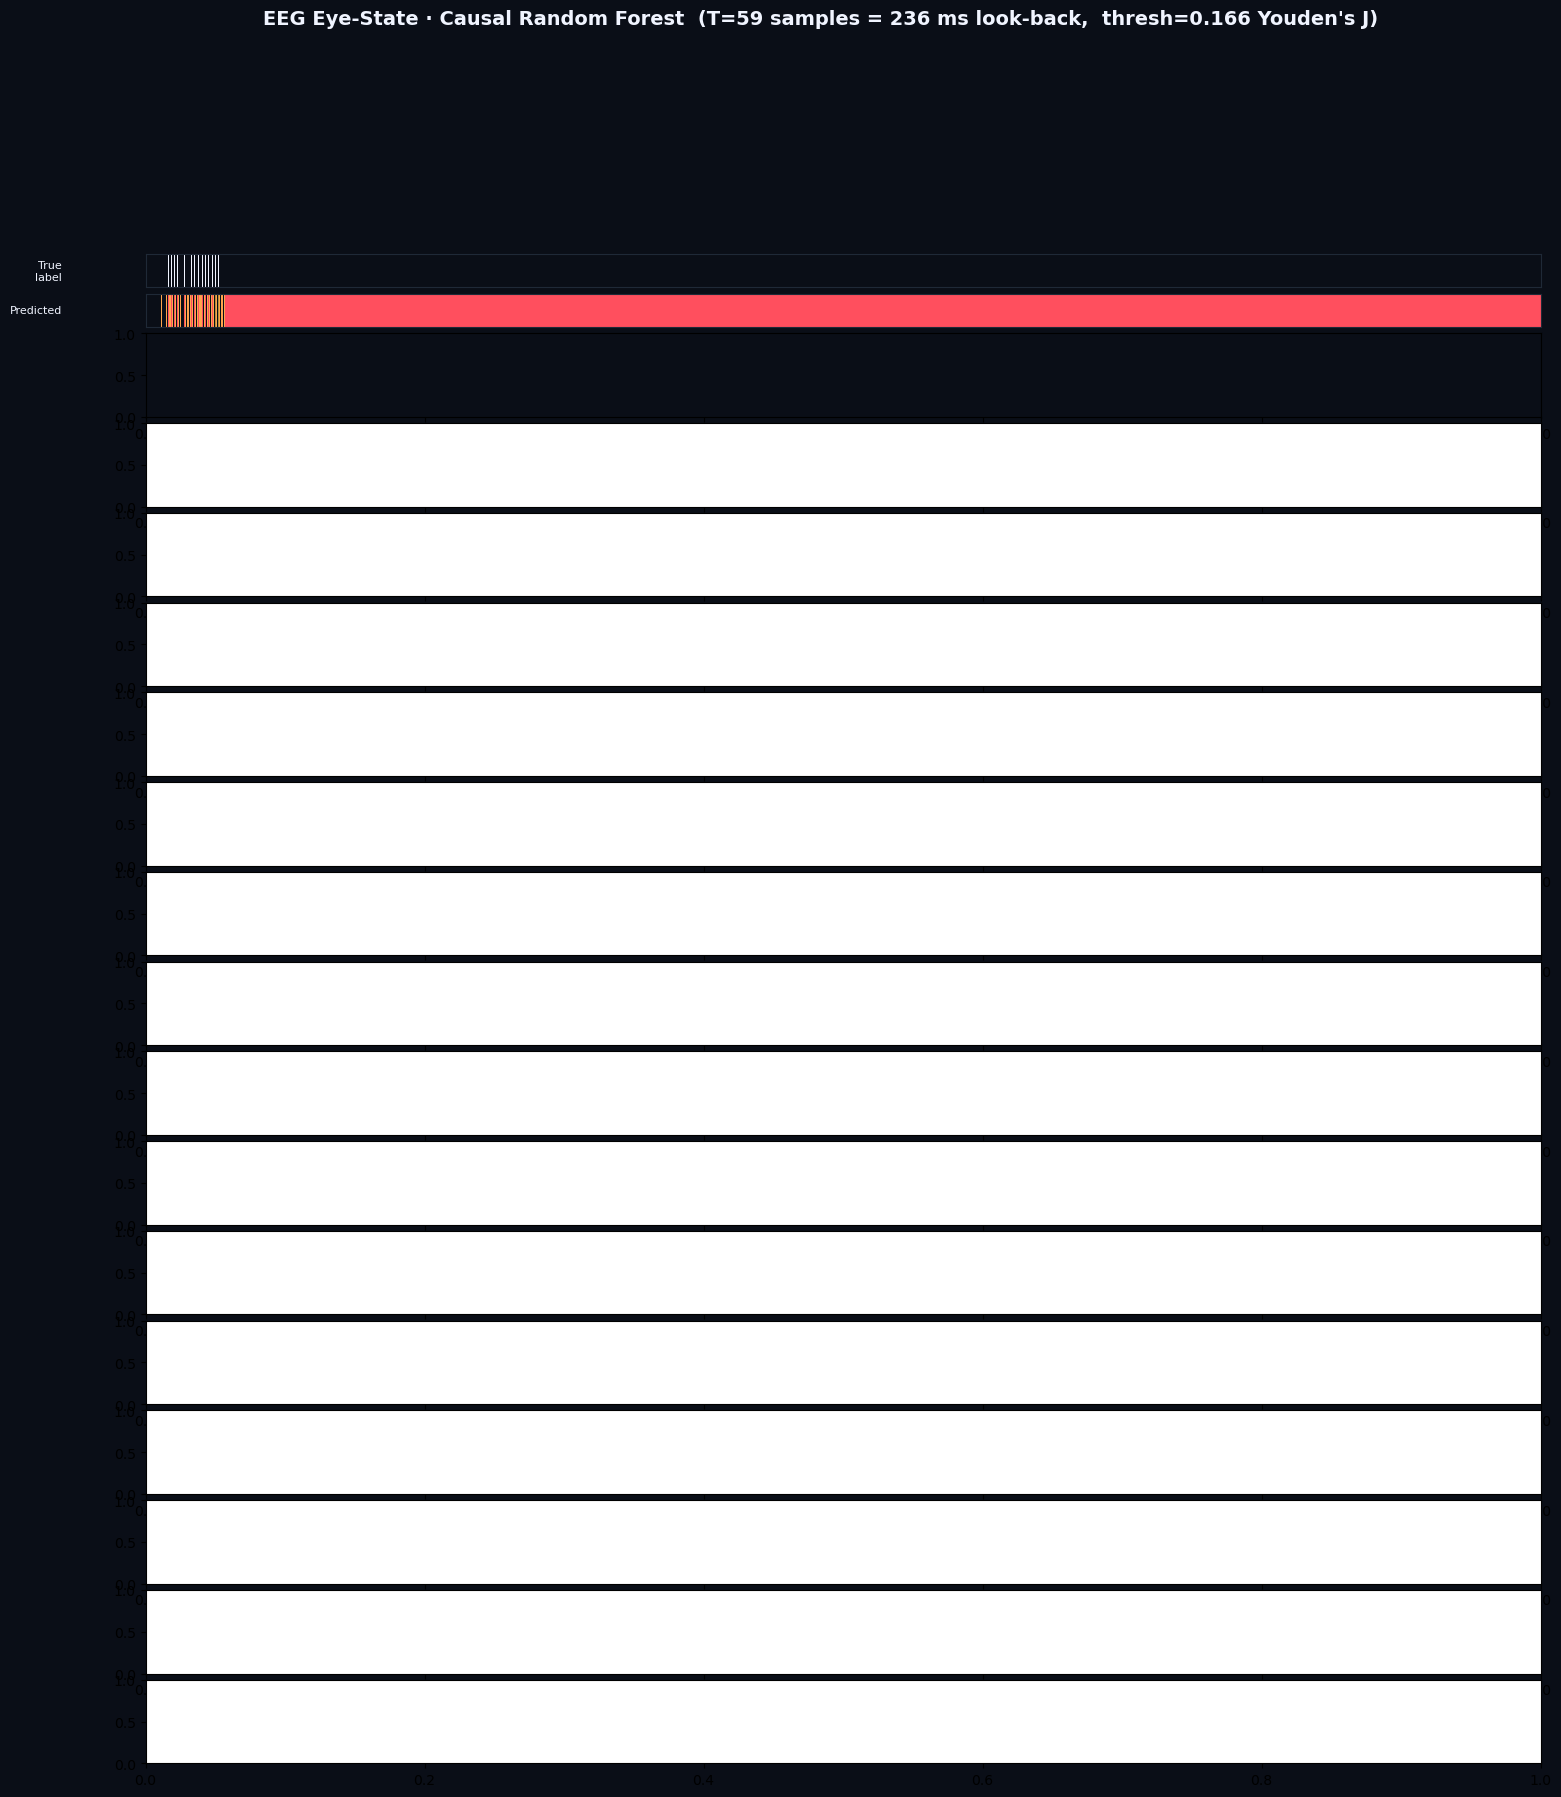

In [18]:
EXCERPT_START = 0
EXCERPT_END = 11_000

sig_start = EXCERPT_START + T
sig_end = EXCERPT_END + T
t_axis = np.arange(sig_start, sig_end)
true_seg = y_win[EXCERPT_START:EXCERPT_END]
pred_seg = all_preds_opt[EXCERPT_START:EXCERPT_END]  # Youden's-J threshold
signal = X_raw[sig_start:sig_end]
L = len(t_axis)

BAR_H = 0.4
CH_H = 1.0
N_ROWS = 2 + N_CHANNELS
row_heights = [BAR_H, BAR_H] + [CH_H] * N_CHANNELS

fig, axes = plt.subplots(
    N_ROWS,
    1,
    figsize=(18, 2.0 + N_CHANNELS * 1.1),
    facecolor=DARK,
    gridspec_kw={"height_ratios": row_heights, "hspace": 0.08},
)
fig.suptitle(
    f"EEG Eye-State · Causal Random Forest  "
    f"(T={T} samples = {T/FS*1000:.0f} ms look-back,  "
    f"thresh={best_thresh:.3f} Youden's J)",
    color=WHITE,
    fontsize=14,
    fontweight="bold",
    y=1.005,
)

x = np.arange(L)


def draw_bar(ax, labels, colour, title):
    ax.set_facecolor(DARK)
    ax.set_xlim(0, L)
    ax.set_ylim(0, 1)
    ax.set_yticks([])
    ax.set_xticks([])
    for sp in ax.spines.values():
        sp.set_color(EDGE)
    in_block = False
    for i, v in enumerate(labels):
        if v == 1 and not in_block:
            block_start = i
            in_block = True
        elif v == 0 and in_block:
            ax.axvspan(block_start, i, color=colour, alpha=1.0, linewidth=0)
            in_block = False
    if in_block:
        ax.axvspan(block_start, L, color=colour, alpha=1.0, linewidth=0)
    ax.set_ylabel(
        title, color=WHITE, fontsize=8, rotation=0, ha="right", va="center", labelpad=60
    )


draw_bar(axes[0], true_seg, colour=WHITE, title="True\nlabel")
draw_bar(axes[1], pred_seg, colour=CORAL, title="Predicted")
for i, err in enumerate(true_seg != pred_seg):
    if err:
        axes[1].axvspan(i, i + 1, color=GOLD, alpha=0.7, linewidth=0)

for ch_i, (ax, ch_name) in enumerate(zip(axes[2:], EEG_COLS)):
    sig_ch = signal[:, ch_i]
    ax.set_facecolor(DARK)
    ax.plot(x, sig_ch, color=TEAL, lw=0.6, alpha=0.85)
    for i in range(L - 1):
        if true_seg[i] == 1:
            ax.axvspan(i, i + 1, alpha=0.08, color=LIME, linewidth=0)
    ax.set_xlim(0, L)
    ax.set_yticks([])
    ax.set_xticks([])
    for sp in ax.spines.values():
        sp.set_color(EDGE)
    ax.set_ylabel(
        ch_name,
        color=WHITE,
        fontsize=8,
        rotation=0,
        ha="right",
        va="center",
        labelpad=5,
    )

tick_s = np.linspace(0, L, 7, dtype=int)
tick_t = np.round((tick_s + sig_start) / FS, 1)
axes[-1].set_xticks(tick_s)
axes[-1].set_xticklabels([f"{s}s" for s in tick_t], color=WHITE, fontsize=8)

from matplotlib.patches import Patch

fig.legend(
    handles=[
        Patch(facecolor=WHITE, label="Eyes open (true)"),
        Patch(facecolor=CORAL, label="Eyes open (pred)"),
        Patch(facecolor=GOLD, label="Mismatch"),
        Patch(facecolor=LIME, alpha=0.4, label="Open region (bg)"),
    ],
    loc="lower center",
    ncol=4,
    facecolor=CARD,
    labelcolor=WHITE,
    edgecolor=EDGE,
    fontsize=9,
    bbox_to_anchor=(0.5, -0.03),
)

## 10 · Plot B — Feature Importance Heatmap

Because features are `(channel, lag)` pairs, we can reshape the importance  
vector into a `(C, T)` matrix and display it as a heatmap.

**Rows:** EEG channels  
**Columns:** time lags (0 = most recent sample before target, T-1 = oldest)  
**Colour:** Gini importance — brighter = more discriminative

This reveals **which channels** and **which temporal offsets** the forest  
relies on most — essentially a learned temporal receptive field.


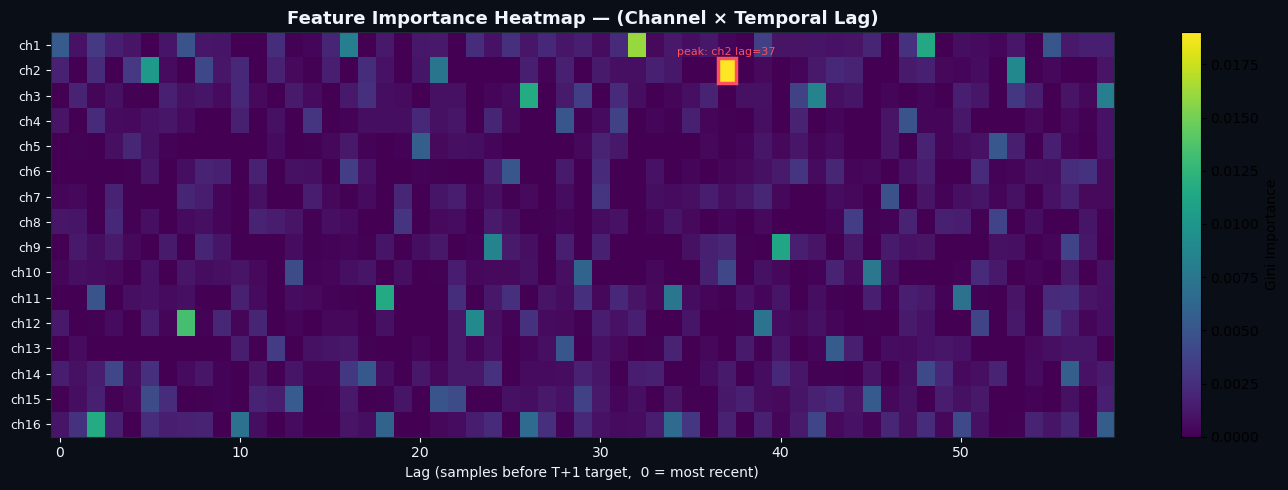

In [19]:
# Reshape importances: (C*T,) → (C, T)
imp_matrix = importances.reshape(N_CHANNELS, T)

fig, ax = plt.subplots(figsize=(14, 5), facecolor=DARK)
ax.set_facecolor(CARD)
for sp in ax.spines.values():
    sp.set_color(EDGE)

im = ax.imshow(imp_matrix, aspect="auto", cmap="viridis", interpolation="nearest")
plt.colorbar(im, ax=ax, label="Gini Importance")

ax.set_yticks(range(N_CHANNELS))
ax.set_yticklabels(EEG_COLS, color=WHITE, fontsize=9)
ax.set_xlabel(
    f"Lag (samples before T+1 target,  0 = most recent)", color=WHITE, fontsize=10
)
ax.set_title(
    "Feature Importance Heatmap — (Channel × Temporal Lag)",
    color=WHITE,
    fontsize=13,
    fontweight="bold",
)
ax.tick_params(colors=WHITE)

# annotate the single most important (channel, lag)
best_ch, best_lag = np.unravel_index(imp_matrix.argmax(), imp_matrix.shape)
ax.add_patch(
    plt.Rectangle(
        (best_lag - 0.5, best_ch - 0.5), 1, 1, fill=False, edgecolor=CORAL, lw=2.5
    )
)
ax.text(
    best_lag,
    best_ch - 0.6,
    f"peak: {EEG_COLS[best_ch]} lag={best_lag}",
    color=CORAL,
    fontsize=8,
    ha="center",
)

plt.tight_layout()

## 11 · Plot C — Per-Channel Total Importance

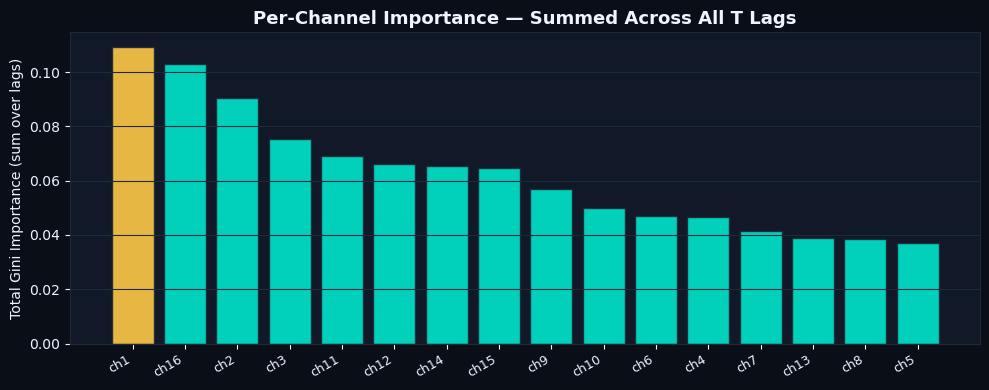

In [20]:
# Sum importance across all lags for each channel
ch_importance = imp_matrix.sum(axis=1)
order = np.argsort(ch_importance)[::-1]

fig, ax = plt.subplots(figsize=(10, 4), facecolor=DARK)
ax.set_facecolor(CARD)
for sp in ax.spines.values():
    sp.set_color(EDGE)

bar_c = [GOLD if i == order[0] else TEAL for i in range(N_CHANNELS)]
ax.bar(
    range(N_CHANNELS),
    ch_importance[order],
    color=[bar_c[np.where(order == i)[0][0]] for i in range(N_CHANNELS)],
    alpha=0.9,
    edgecolor=EDGE,
)
ax.set_xticks(range(N_CHANNELS))
ax.set_xticklabels(
    [EEG_COLS[i] for i in order], color=WHITE, fontsize=9, rotation=30, ha="right"
)
ax.set_ylabel("Total Gini Importance (sum over lags)", color=WHITE, fontsize=10)
ax.set_title(
    "Per-Channel Importance — Summed Across All T Lags",
    color=WHITE,
    fontsize=13,
    fontweight="bold",
)
ax.tick_params(colors=WHITE)
ax.yaxis.grid(True, color=EDGE, lw=0.8)

plt.tight_layout()

## 12 · Plot D — Window Size T vs AUC

Scatter plot of T against trial AUC across all Optuna trials.  
Reveals the optimal look-back duration and how sensitive performance is to it.


Text(0.5, 0.98, 'Optuna Search — Causal Random Forest')

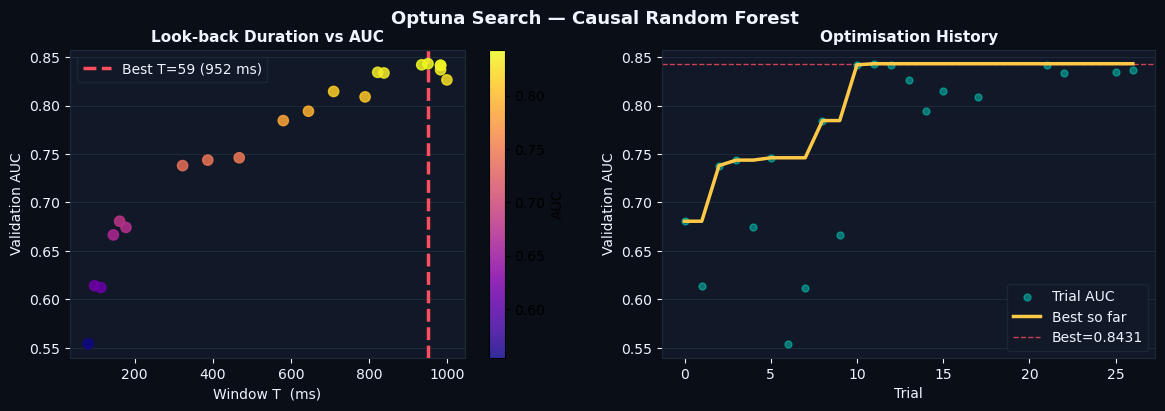

In [21]:
trials_df = study.trials_dataframe(attrs=("number", "value", "params", "state"))
comp = trials_df[trials_df["state"] == "COMPLETE"].sort_values("number")

col_T = "params_T"
fig, axes = plt.subplots(1, 2, figsize=(14, 4), facecolor=DARK)

# left: T vs AUC
ax = axes[0]
ax.set_facecolor(CARD)
for sp in ax.spines.values():
    sp.set_color(EDGE)
if col_T in comp.columns:
    T_vals = comp[col_T].dropna().values
    auc_vals = comp.loc[comp[col_T].notna(), "value"].values
    sc = ax.scatter(
        T_vals / FS_EFF * 1000,
        auc_vals,
        c=auc_vals,
        cmap="plasma",
        s=55,
        alpha=0.85,
        zorder=3,
    )
    ax.axvline(
        T / FS_EFF * 1000,
        color=CORAL,
        lw=2.5,
        ls="--",
        label=f"Best T={T} ({T/FS_EFF*1000:.0f} ms)",
    )
    plt.colorbar(sc, ax=ax, label="AUC")
ax.set_xlabel("Window T  (ms)", color=WHITE, fontsize=10)
ax.set_ylabel("Validation AUC", color=WHITE, fontsize=10)
ax.set_title("Look-back Duration vs AUC", color=WHITE, fontsize=11, fontweight="bold")
ax.tick_params(colors=WHITE)
ax.yaxis.grid(True, color=EDGE)
ax.legend(facecolor=CARD, labelcolor=WHITE, edgecolor=EDGE)

# right: optimisation history
ax = axes[1]
ax.set_facecolor(CARD)
for sp in ax.spines.values():
    sp.set_color(EDGE)
vals = comp["value"].values
nums = comp["number"].values
best_sf = np.maximum.accumulate(vals)
ax.scatter(nums, vals, color=TEAL, alpha=0.45, s=25, zorder=3, label="Trial AUC")
ax.plot(nums, best_sf, color=GOLD, lw=2.5, zorder=4, label="Best so far")
ax.axhline(
    best_sf[-1], color=CORAL, lw=1, ls="--", label=f"Best={best_sf[-1]:.4f}", alpha=0.8
)
ax.set_xlabel("Trial", color=WHITE, fontsize=10)
ax.set_ylabel("Validation AUC", color=WHITE, fontsize=10)
ax.set_title("Optimisation History", color=WHITE, fontsize=11, fontweight="bold")
ax.tick_params(colors=WHITE)
ax.yaxis.grid(True, color=EDGE)
ax.legend(facecolor=CARD, labelcolor=WHITE, edgecolor=EDGE)

plt.suptitle(
    "Optuna Search — Causal Random Forest", color=WHITE, fontsize=13, fontweight="bold"
)


## 13 · Plot E — Confusion Matrix

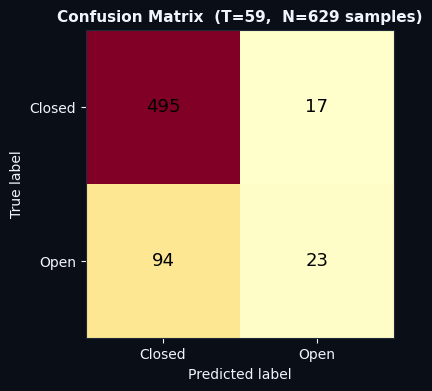

In [22]:
fig, ax = plt.subplots(figsize=(5, 4), facecolor=DARK)
ax.set_facecolor(CARD)
for sp in ax.spines.values():
    sp.set_color(EDGE)

cm = confusion_matrix(y_win[mask], all_preds[mask])
disp = ConfusionMatrixDisplay(cm, display_labels=["Closed", "Open"])
disp.plot(ax=ax, colorbar=False, cmap="YlOrRd")

ax.set_title(
    f"Confusion Matrix  (T={T},  N={mask.sum():,} samples)",
    color=WHITE,
    fontsize=11,
    fontweight="bold",
)
ax.tick_params(colors=WHITE)
ax.xaxis.label.set_color(WHITE)
ax.yaxis.label.set_color(WHITE)
for txt in ax.texts:
    txt.set_color("black")
    txt.set_fontsize(13)

## 14 · Results Summary

In [23]:
acc = (all_preds[mask] == y_win[mask]).mean()
acc_opt = (all_preds_opt[mask] == y_win[mask]).mean()
# top3_idx = np.argsort(ch_importance)[::-1][:3]

print("=" * 60)
print("  EEG trigger pressing — Causal Random Forest Results")
print("=" * 60)
print(f"  Look-back window  : T = {T} samples  ({T/FS*1000:.0f} ms)")
print(
    f"  Feature vector    : {N_CHANNELS} channels × {T} lags = {N_CHANNELS*T} features"
)
print(f"  Predicts          : eye state at sample T+1")
print(f"  Dataset size      : {X_win.shape[0]:,} windows")
print()
print(f"  Best trial AUC    : {study.best_value:.4f}")
print(f"  CV AUC (5-fold)   : {np.mean(final_aucs):.4f} ± {np.std(final_aucs):.4f}")
print(f"  Accuracy @ 0.5    : {acc:.4f}")
print(f"  Accuracy @ optimal threshold ({best_thresh:.3f}) : {acc_opt:.4f}")
print()
print("  Best RF Config")
print(f"    n_estimators      : {n_estimators}")
print(f"    max_depth         : {max_depth}")
print(f"    min_samples_split : {min_samples_split}")
print(f"    min_samples_leaf  : {min_samples_leaf}")
print(f"    max_features      : {max_features}")
print(f"    class_weight      : {class_weight}")
print()
print("  Top 3 most important channels:")
# for i in top3_idx:
#    print(f"    {EEG_COLS[i]:6s}  total importance = {ch_importance[i]:.4f}")
# print("=" * 60)

  EEG trigger pressing — Causal Random Forest Results
  Look-back window  : T = 59 samples  (236 ms)
  Feature vector    : 16 channels × 59 lags = 944 features
  Predicts          : eye state at sample T+1
  Dataset size      : 629 windows

  Best trial AUC    : 0.8431
  CV AUC (5-fold)   : 0.8324 ± 0.0596
  Accuracy @ 0.5    : 0.8235
  Accuracy @ optimal threshold (0.166) : 0.6423

  Best RF Config
    n_estimators      : 60
    max_depth         : 30
    min_samples_split : 15
    min_samples_leaf  : 3
    max_features      : sqrt
    class_weight      : None

  Top 3 most important channels:


In [24]:
import json

import joblib

SAVE_PATH = f"../data/subject{subject}/model"

if not os.path.isdir(SAVE_PATH):
    os.makedirs(SAVE_PATH)

# Calibrated model is used for inference (raw RF kept for feature importance only)
joblib.dump(best_clf, f"{SAVE_PATH}/eeg_rf_model.joblib")
joblib.dump(calibrated_clf, f"{SAVE_PATH}/eeg_rf_calibrated.joblib")

params_to_save = {
    "T": int(T),
    "n_estimators": int(n_estimators),
    "max_depth": max_depth,
    "min_samples_split": int(min_samples_split),
    "min_samples_leaf": int(min_samples_leaf),
    "max_features": max_features,
    "class_weight": class_weight,
    "best_cv_auc": float(np.mean(final_aucs)),
    "best_thresh": best_thresh,
    "n_channels": int(N_CHANNELS),
    "channel_names": EEG_COLS,
    "fs": int(FS),
    "per_window_norm": True,
}
with open(f"{SAVE_PATH}/eeg_rf_params.json", "w") as f:
    json.dump(params_to_save, f, indent=2)

print("Saved:")
print(f"  {SAVE_PATH}/eeg_rf_model.joblib       (raw RF — feature importance)")
print(f"  {SAVE_PATH}/eeg_rf_calibrated.joblib  (calibrated — used by server)")
print(f"  {SAVE_PATH}/eeg_rf_params.json         (T={T}, thresh={best_thresh:.3f})")

Saved:
  ../data/subject9/model/eeg_rf_model.joblib       (raw RF — feature importance)
  ../data/subject9/model/eeg_rf_calibrated.joblib  (calibrated — used by server)
  ../data/subject9/model/eeg_rf_params.json         (T=59, thresh=0.166)


## 15 · Predict on a New Trial

Apply the trained model to a held-out trial.

**Pipeline for new data:**
1. Band-pass filter (same as training)
2. Build windows with `per_window_norm=True` — no scaler needed, each window is self-normalised
3. Predict with the **calibrated** classifier
4. Apply the **optimal threshold** (Youden's J) found during training CV

In [25]:
print("Loading new trial …")

subject = 9
tache = "spt"
trial = 2
data_path = f"../data/subject{subject}/"

df_new, EEG_COLS_NEW = load_trial(
    subject, tache, trial, data_path, eeg_cols=EEG_COLS, apply_filter=False
)

print(f"  Shape : {df_new.shape}")
print(f"  Class balance:\n{df_new['button'].value_counts()}\n")

Loading new trial …
  Shape : (15563, 18)
  Class balance:
button
0    12571
1     2992
Name: count, dtype: int64



In [ ]:
# Band-pass filter + decimate — identical settings as training
if APPLY_CLEANING:
    df_new = remove_artifacts_interpolate(df_new, EEG_COLS, Q_UPPER, Q_LOWER, MARGIN)
else:
    print("Artifact removal skipped.")

df_new.iloc[:, 1:-1] = filter_data(df_new.iloc[:, 1:-1].values.T, FS, 0.5, 8).T

if DECIMATE > 1:
    from scipy.signal import decimate as sp_decimate
    eeg_decimated = sp_decimate(df_new[EEG_COLS].values, DECIMATE, axis=0, zero_phase=True)
    n_out = eeg_decimated.shape[0]
    df_new = df_new.iloc[::DECIMATE].iloc[:n_out].reset_index(drop=True)
    df_new[EEG_COLS] = eeg_decimated
    print(f"Decimated to {FS_EFF} Hz  |  samples: {len(df_new):,}")

In [27]:
# No scaler.transform needed — per_window_norm handles amplitude normalisation
X_new = df_new[EEG_COLS].values.astype(np.float32)
y_new = make_horizon_labels(df_new[TARGET].values.astype(int), HORIZON)

In [28]:
X_win_new, y_win_new = build_windows(X_new, y_new, T, stride=STRIDE, per_window_norm=True)
print(f"New trial windows : {X_win_new.shape}  labels : {X_win_new.shape[0]}")

New trial windows : (1938, 944)  labels : 1938


In [29]:
# Smooth probabilities before thresholding (same pipeline as training)
probs_new = smooth_probs(calibrated_clf.predict_proba(X_win_new)[:, 1])
preds_new = (probs_new >= best_thresh).astype(int)
auc_new = roc_auc_score(y_win_new, probs_new)
acc_new = (preds_new == y_win_new).mean()

print(
    f"New trial — AUC : {auc_new:.4f}   Accuracy : {acc_new:.4f}  (threshold={best_thresh:.3f})"
)
print()
print(classification_report(y_win_new, preds_new, target_names=["Closed", "Open"]))

New trial — AUC : 0.6135   Accuracy : 0.4809  (threshold=0.166)

              precision    recall  f1-score   support

      Closed       0.87      0.38      0.53      1480
        Open       0.29      0.82      0.43       458

    accuracy                           0.48      1938
   macro avg       0.58      0.60      0.48      1938
weighted avg       0.73      0.48      0.50      1938



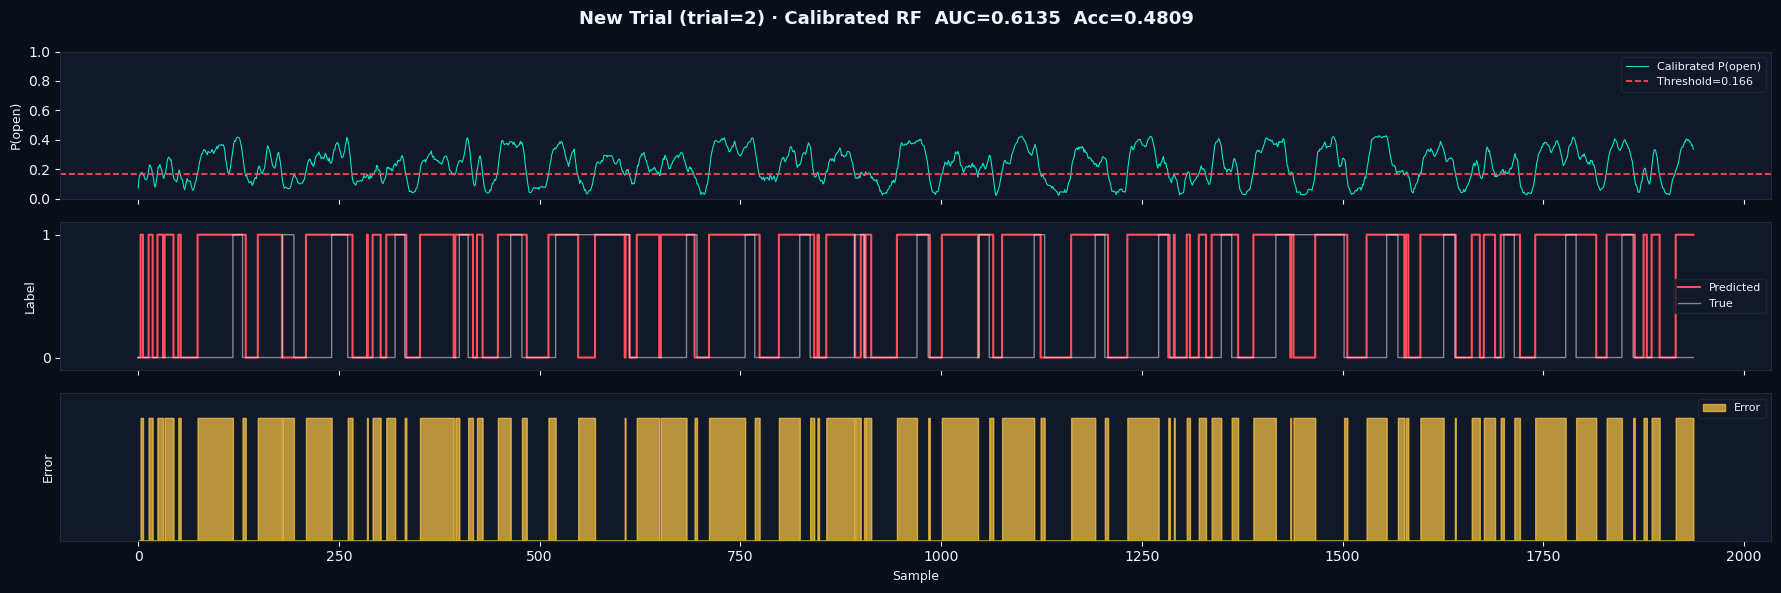

In [30]:
%matplotlib inline
fig, axes = plt.subplots(3, 1, figsize=(18, 6), sharex=True, facecolor=DARK)

t = np.arange(len(probs_new))

ax = axes[0]
ax.set_facecolor(CARD)
ax.plot(t, probs_new, color=TEAL, lw=0.8, label="Calibrated P(open)")
ax.axhline(
    best_thresh, color=CORAL, lw=1.2, ls="--", label=f"Threshold={best_thresh:.3f}"
)
ax.set_ylim(0, 1)
ax.set_ylabel("P(open)", color=WHITE, fontsize=9)
ax.tick_params(colors=WHITE)
ax.legend(facecolor=CARD, labelcolor=WHITE, edgecolor=EDGE, fontsize=8)
for sp in ax.spines.values():
    sp.set_color(EDGE)

ax = axes[1]
ax.set_facecolor(CARD)
ax.plot(t, preds_new, drawstyle="steps-post", color=CORAL, lw=1.5, label="Predicted")
ax.plot(
    t, y_win_new, drawstyle="steps-post", color=WHITE, lw=1.0, alpha=0.5, label="True"
)
ax.set_ylim(-0.1, 1.1)
ax.set_yticks([0, 1])
ax.set_ylabel("Label", color=WHITE, fontsize=9)
ax.tick_params(colors=WHITE)
ax.legend(facecolor=CARD, labelcolor=WHITE, edgecolor=EDGE, fontsize=8)
for sp in ax.spines.values():
    sp.set_color(EDGE)

ax = axes[2]
ax.set_facecolor(CARD)
errors = (preds_new != y_win_new).astype(float)
ax.fill_between(t, errors, color=GOLD, alpha=0.7, step="post", label="Error")
ax.set_ylim(0, 1.2)
ax.set_yticks([])
ax.set_ylabel("Error", color=WHITE, fontsize=9)
ax.set_xlabel("Sample", color=WHITE, fontsize=9)
ax.tick_params(colors=WHITE)
ax.legend(facecolor=CARD, labelcolor=WHITE, edgecolor=EDGE, fontsize=8)
for sp in ax.spines.values():
    sp.set_color(EDGE)

fig.suptitle(
    f"New Trial (trial={trial}) · Calibrated RF  AUC={auc_new:.4f}  Acc={acc_new:.4f}",
    color=WHITE,
    fontsize=13,
    fontweight="bold",
)
plt.tight_layout()

In [ ]:
%matplotlib inline
# ── Predict on all other trials ───────────────────────────────────────────
OTHER_TRIALS = [t for t in range(10) if t != trial]

results = []

for t in OTHER_TRIALS:
    df_t, _ = load_trial(subject, tache, t, data_path, eeg_cols=EEG_COLS, decimate=DECIMATE, lp=0.5, hp=8)

    X_t = df_t[EEG_COLS].values.astype(np.float32)
    y_t = make_horizon_labels(df_t[TARGET].values.astype(int), HORIZON)

    X_win_t, y_win_t = build_windows(X_t, y_t, T, stride=STRIDE, per_window_norm=True)

    # Smooth before thresholding — same pipeline as training
    probs_t = smooth_probs(calibrated_clf.predict_proba(X_win_t)[:, 1])
    preds_t = (probs_t >= best_thresh).astype(int)
    auc_t = roc_auc_score(y_win_t, probs_t)
    acc_t = (preds_t == y_win_t).mean()
    results.append(
        {
            "trial": t,
            "auc": auc_t,
            "acc": acc_t,
            "probs": probs_t,
            "preds": preds_t,
            "y": y_win_t,
        }
    )
    print(f"  trial {t:2d}: AUC={auc_t:.4f}  Acc={acc_t:.4f}  n={len(y_win_t):,}")

aucs = [r["auc"] for r in results]
accs = [r["acc"] for r in results]
print(f"\nMean AUC : {np.mean(aucs):.4f} ± {np.std(aucs):.4f}")
print(f"Mean Acc : {np.mean(accs):.4f} ± {np.std(accs):.4f}")

# ── 3-panel figure per trial ──────────────────────────────────────────────
for r in results:
    fig, axes = plt.subplots(3, 1, figsize=(18, 6), sharex=True, facecolor=DARK)
    t_axis = np.arange(len(r["probs"]))

    ax = axes[0]
    ax.set_facecolor(CARD)
    ax.plot(t_axis, r["probs"], color=TEAL, lw=0.8, label="Calibrated P(press)")
    ax.axhline(
        best_thresh, color=CORAL, lw=1.2, ls="--", label=f"Threshold={best_thresh:.3f}"
    )
    ax.set_ylim(0, 1)
    ax.set_ylabel("P(press)", color=WHITE, fontsize=9)
    ax.tick_params(colors=WHITE)
    ax.legend(facecolor=CARD, labelcolor=WHITE, edgecolor=EDGE, fontsize=8)
    for sp in ax.spines.values():
        sp.set_color(EDGE)

    ax = axes[1]
    ax.set_facecolor(CARD)
    ax.plot(t_axis, r["preds"], drawstyle="steps-post", color=CORAL, lw=1.5, label="Predicted")
    ax.plot(t_axis, r["y"], drawstyle="steps-post", color=WHITE, lw=1.0, alpha=0.5, label="True")
    ax.set_ylim(-0.1, 1.1)
    ax.set_yticks([0, 1])
    ax.set_ylabel("Label", color=WHITE, fontsize=9)
    ax.tick_params(colors=WHITE)
    ax.legend(facecolor=CARD, labelcolor=WHITE, edgecolor=EDGE, fontsize=8)
    for sp in ax.spines.values():
        sp.set_color(EDGE)

    ax = axes[2]
    ax.set_facecolor(CARD)
    errors = (r["preds"] != r["y"]).astype(float)
    ax.fill_between(t_axis, errors, color=GOLD, alpha=0.7, step="post", label="Error")
    ax.set_ylim(0, 1.2)
    ax.set_yticks([])
    ax.set_ylabel("Error", color=WHITE, fontsize=9)
    ax.set_xlabel("Sample", color=WHITE, fontsize=9)
    ax.tick_params(colors=WHITE)
    ax.legend(facecolor=CARD, labelcolor=WHITE, edgecolor=EDGE, fontsize=8)
    for sp in ax.spines.values():
        sp.set_color(EDGE)

    fig.suptitle(
        f"Trial {r['trial']} · Calibrated RF  AUC={r['auc']:.4f}  Acc={r['acc']:.4f}",
        color=WHITE, fontsize=13, fontweight="bold",
    )
    plt.tight_layout()
    plt.show()